C:\Users\garyf\AppData\Local\Temp\ipykernel_5296\1486997481.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("^HSI", start="2023-01-01", end="2025-07-01")
[*********************100%***********************]  1 of 1 completed


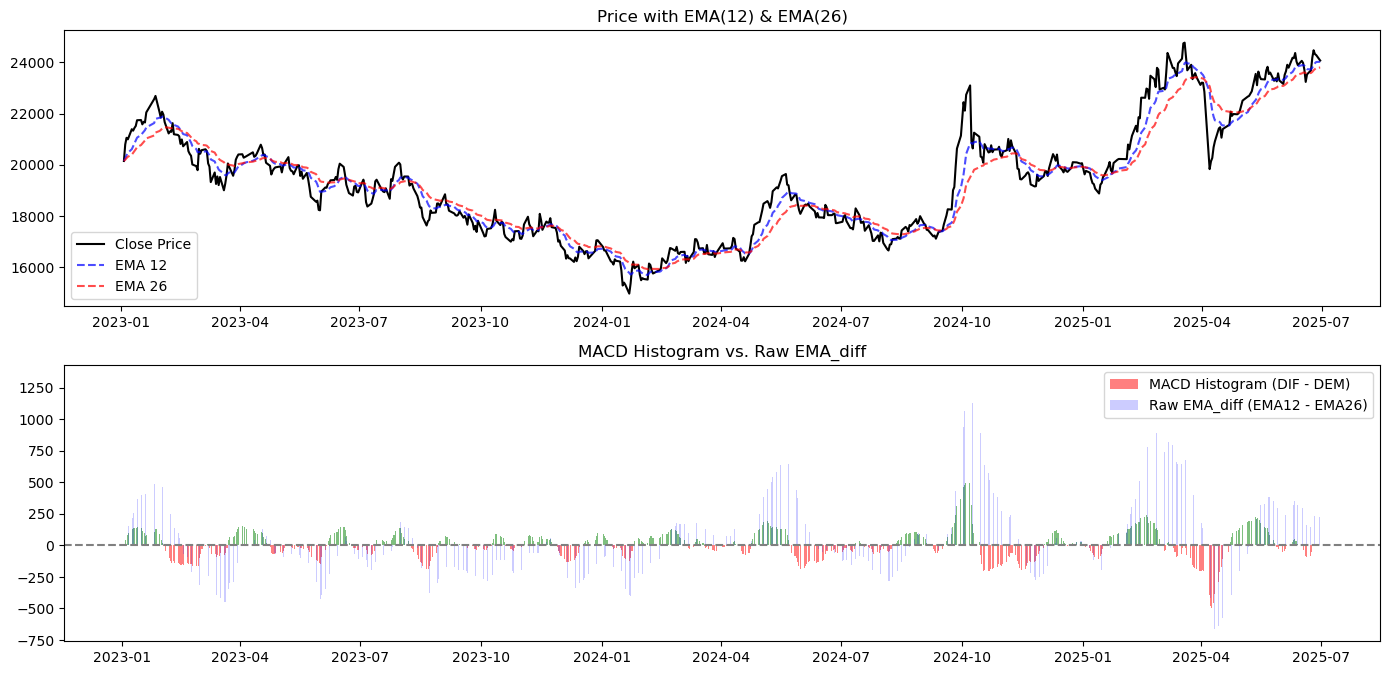

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# 下載數據（以台積電為例）
data = yf.download("^HSI", start="2023-01-01", end="2025-07-01")

def calculate_compare_macd(data, fast=12, slow=26, signal=9):
    # 計算 EMA
    data['EMA12'] = data['Close'].ewm(span=fast, adjust=False).mean()
    data['EMA26'] = data['Close'].ewm(span=slow, adjust=False).mean()
    
    # 方法1: 傳統 MACD (DIF = EMA12 - EMA26, DEM = DIF的9日EMA)
    data['DIF'] = data['EMA12'] - data['EMA26']
    data['DEM'] = data['DIF'].ewm(span=signal, adjust=False).mean()
    data['MACD_Hist'] = data['DIF'] - data['DEM']  # 傳統MACD柱狀圖
    
    # 方法2: 直接計算 EMA12 - EMA26 的差值
    data['EMA_diff'] = data['EMA12'] - data['EMA26']  # 新增欄位
    
    return data

data = calculate_compare_macd(data)

# 繪製比較圖
plt.figure(figsize=(14, 10))
ax1 = plt.subplot(3, 1, 2)
ax1.plot(data['Close'], label='Close Price', color='black')
ax1.plot(data['EMA12'], label='EMA 12', color='blue', linestyle='--', alpha=0.7)
ax1.plot(data['EMA26'], label='EMA 26', color='red', linestyle='--', alpha=0.7)
ax1.set_title('Price with EMA(12) & EMA(26)')
ax1.legend()

ax3 = plt.subplot(3, 1, 3)
ax3.bar(data.index, data['MACD_Hist'], label='MACD Histogram (DIF - DEM)', 
        color=np.where(data['MACD_Hist'] > 0, 'green', 'red'), alpha=0.5)
ax3.bar(data.index, data['EMA_diff'], label='Raw EMA_diff (EMA12 - EMA26)', 
        color='blue', alpha=0.2, width=0.3)
ax3.axhline(0, color='gray', linestyle='--')
ax3.set_title('MACD Histogram vs. Raw EMA_diff')
ax3.legend()

plt.tight_layout()
plt.show()

In [1]:
import sys
import pandas as pd
import numpy as np
import os
from datetime import datetime
from pathlib import Path
import json

from testing.yfinance_utils import get_yfinance_data
from testing.ticker_utils import load_tickers_from_ini
from testing.zscore_utils import calculate_z_scores
from testing.ema_utils import calculate_ema_bands
from testing.confidence_utils import calculate_confidence_levels, calculate_downside_risk
from testing.calculate_macd import calculate_macd
from testing.volume_analysis import calculate_obv
from testing.calculate_bollinger_bands import calculate_bollinger_bands

# 傳統方式定義檔案路徑
INI_FILE = fr"D:/ftpdemo/HK_RANK.ini"
OUTPUT_JSON = fr"D:/ftpdemo/PINKY_ALERT.json"

def rsi_function(close, sensitivity, rsi_period, rsi_base):
    delta = close.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=rsi_period, min_periods=1).mean()
    avg_loss = loss.rolling(window=rsi_period, min_periods=1).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    rsi = sensitivity * (rsi - rsi_base) + 50
    return np.clip(rsi, 0, 100)

def get_bb_trend(macd_hist, prev_macd_hist, price, bb_lower, bb_upper):
    hist_improving = (macd_hist > prev_macd_hist) if (macd_hist < 0 and prev_macd_hist < 0) else False
    price_at_lower = price <= bb_lower
    price_at_upper = price >= bb_upper
    if hist_improving and price_at_lower:
        return "BB Buy Signal"
    elif hist_improving and price_at_upper:
        return "BB Sell Signal"
    else:
        return "Neutral"

def get_macd_trend(macd_line, signal_line, histogram):
    if ((macd_line > signal_line) and histogram > 0) or ((macd_line > signal_line) and histogram < 0):
        return "UP Trend"
    elif ((macd_line < signal_line) and histogram < 0) or ((macd_line < signal_line) and histogram > 0):
        return "Down Trend"
    return "Neutral"

def analyze_stock(ticker_data):
    close = ticker_data['Close']
    volume = ticker_data['Volume']
    obv = calculate_obv(close, volume)
    return {'OBV_Trend': 'Up' if obv.iloc[-1] > obv.iloc[-2] else 'Down'}

def rankings(tickers, names, end_date):
    COLS = [
        'Ticker', 'Name',
        'OBV_Trend', 'Price', 'Z_Score_30',
        'EMA_Short_Lower', 'EMA_Long_Upper', 'EMA_Trend_Signal', 'ema_diff',
        '89%潛在風險', '90%潛在風險', '95%潛在風險',
        '動能指標','MACD','MACD_Signal','MACD_Hist','MACD_Trend',
        'BB_Upper','BB_Lower','BB_Trend',
        'Date','蹺蹺板狀態'
    ]
    result = []
    ticker_to_name = dict(zip(tickers, names))
    price_data = get_yfinance_data(tickers)
    for ticker in tickers:
        try:
            if ticker not in price_data:
                continue
            ticker_data = price_data[ticker]
            closes = ticker_data['Close'].dropna()
            if len(closes) < 20:
                continue
            last_price = closes.iloc[-1]
            custom_rsi = rsi_function(closes, 1.5, 50, 50)
            latest_rsi = custom_rsi.iloc[-1]
            confidence_data = calculate_confidence_levels(closes)
            ema_results = calculate_ema_bands(ticker_data['High'], ticker_data['Low'], closes)
            z_scores = calculate_z_scores(closes, [30])
            latest_lower_89 = confidence_data['lower_89'].iloc[-1]
            latest_lower_90 = confidence_data['lower_90'].iloc[-1]
            latest_lower_95 = confidence_data['lower_95'].iloc[-1]
            z_score_30 = z_scores[30] if 30 in z_scores else np.nan
            downside_risk = calculate_downside_risk(
                last_price, latest_lower_89, latest_lower_90, latest_lower_95
            )
            macd_results = calculate_macd(closes)
            bb_results = calculate_bollinger_bands(closes)
            latest_macd = macd_results['macd'].iloc[-1]
            latest_signal = macd_results['signal'].iloc[-1]
            latest_histogram = macd_results['histogram'].iloc[-1]
            latest_bb_upper = bb_results['upper'].iloc[-1]
            latest_bb_lower = bb_results['lower'].iloc[-1]
            prev_histogram = macd_results['histogram'].iloc[-2] if len(macd_results['histogram']) > 1 else 0
            volume_analysis = analyze_stock(ticker_data)
            result.append({
                'Ticker': ticker,
                'Name': ticker_to_name[ticker],
                'OBV_Trend': volume_analysis['OBV_Trend'],
                'Price': round(last_price, 2),
                'Z_Score_30': round(z_score_30, 2) if not pd.isna(z_score_30) else None,
                'EMA_Short_Lower': round(ema_results['short_lower'], 2),
                'EMA_Long_Upper': round(ema_results['long_upper'], 2),
                'EMA_Trend_Signal': ema_results['trend_signal'],
                '89%潛在風險': round(downside_risk['latest_lower_89'],2),
                '90%潛在風險': round(downside_risk['latest_lower_90'],2),
                '95%潛在風險': round(downside_risk['latest_lower_95'],2),                
                '動能指標': round(latest_rsi, 2),
                'MACD': round(latest_macd, 3),
                'MACD_Signal': round(latest_signal, 3),
                'MACD_Hist': round(latest_histogram, 3),
                'MACD_Trend': get_macd_trend(latest_macd, latest_signal, latest_histogram),
                'BB_Upper': round(latest_bb_upper, 2),
                'BB_Lower': round(latest_bb_lower, 2),
                'BB_Trend': get_bb_trend(latest_histogram, prev_histogram, last_price, latest_bb_lower, latest_bb_upper),
                'ema_diff': round(ema_results['short_lower'] - ema_results['long_upper'], 2),
                'Date': end_date.strftime('%Y-%m-%d'),
                '蹺蹺板狀態': "藍區" if ((round(ema_results['short_lower'] - ema_results['long_upper'], 2)) > 0) and (latest_histogram > 0) else "紅區"
            })
        except Exception as e:
            print(f"Error processing {ticker}: {str(e)}")
    return pd.DataFrame(result)[COLS] if result else pd.DataFrame(columns=COLS)

def main():
    tickers, names = load_tickers_from_ini(INI_FILE)
    end_date1 = datetime.now()
    df = rankings(tickers, names, end_date1)
    print(df)
    if not df.empty:
        df.to_json(OUTPUT_JSON, orient='records', force_ascii=False, indent=4)
        output_csv = OUTPUT_JSON.replace('.json', '.csv')
        df.to_csv(output_csv, index=False, encoding='utf-8-sig')
        print(f"Results saved to {OUTPUT_JSON} and {output_csv}")
    else:
        print("No data available to save.")

if __name__ == "__main__":
    main()

     Ticker      Name OBV_Trend   Price  Z_Score_30  EMA_Short_Lower  \
0   0001.HK        長和        Up   48.90        0.91            47.45   
1   0005.HK      匯豐控股        Up   98.15        1.70            94.79   
2   0386.HK  中國石油化工股份        Up    4.33        1.71             4.18   
3   0388.HK     香港交易所        Up  429.60        1.47           410.53   
4   0688.HK    中國海外發展        Up   13.40       -0.19            13.30   
5   0700.HK      騰訊控股        Up  517.50        1.30           502.55   
6   0762.HK      中國聯通        Up    9.38        0.32             9.17   
7   0823.HK    領展房產基金      Down   42.20        0.34            41.50   
8   0836.HK      華潤電力        Up   19.54        0.03            19.25   
9   0857.HK    中國石油股份        Up    7.22        1.78             6.83   
10  0868.HK      信義玻璃        Up    8.18        0.62             7.88   
11  2899.HK      紫金礦業        Up   20.90        1.31            19.66   
12  3690.HK        美團        Up  127.20       -0.31           12